In [18]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from matplotlib.pyplot import subplots
import polars as pl
import polars.selectors as cs
from marginaleffects import fit_sklearn, avg_slopes, avg_comparisons
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, roc_auc_score, 
roc_curve, RocCurveDisplay, ConfusionMatrixDisplay, precision_recall_curve,
log_loss)

In [2]:
# This is the dataset download function from Auerlion Geron's HOML vignette, from which this 
# example originated

def load_titanic_data():
    tarball_path = Path("datasets/titanic.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/titanic.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as titanic_tarball:
            titanic_tarball.extractall(path="datasets", filter="data")
    return [pd.read_csv(Path("datasets/titanic") / filename)
            for filename in ("train.csv", "test.csv")]

In [64]:
titanic_train_data, titanic_test_data = load_titanic_data()

In [62]:
titanic_train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [63]:
titanic_train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [70]:
titanic_train_data.set_index("PassengerId",inplace=True)

In [71]:

X = titanic_train_data.drop("Survived",axis=1)
y = titanic_train_data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=19831921)

In [72]:
y_train

PassengerId
869    0
40     1
768    0
844    0
653    0
      ..
169    0
856    1
162    1
364    0
404    0
Name: Survived, Length: 712, dtype: int64

In [11]:
X_train["Age"].median()

np.float64(28.0)

In [12]:
X_train.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,712.000000,712.000000,571.000000,712.000000,712.000000,712.000000
mean,439.717697,2.323034,29.510946,0.522472,0.383427,31.848396
std,258.036659,0.828214,14.332531,1.104676,0.811594,50.786391
min,1.000000,1.000000,0.666700,0.000000,0.000000,0.000000
25%,214.750000,2.000000,20.750000,0.000000,0.000000,7.925000
50%,434.000000,3.000000,28.000000,0.000000,0.000000,14.427100
75%,664.250000,3.000000,38.000000,1.000000,0.000000,30.017700
max,890.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
y_train.value_counts()

Survived
0    437
1    275
Name: count, dtype: int64

In [16]:
X_train["Pclass"].value_counts()

Pclass
3    396
1    166
2    150
Name: count, dtype: int64

In [17]:
X_train["Sex"].value_counts()

Sex
male      460
female    252
Name: count, dtype: int64

In [23]:
num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median",add_indicator=True)),
    ("scaler",StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("cat_encoder",OneHotEncoder(sparse_output=False,drop="first"))
])

num_attribs = ["Age","SibSp","Parch","Fare"]
cat_attribs = ["Pclass","Sex","Embarked"]


preprocess_pipeline = ColumnTransformer([
    ("num",num_pipeline,num_attribs),
    ("cat",cat_pipeline,cat_attribs)
])




In [30]:
preprocess_pipeline.fit(X_train)

preprocess_pipeline.get_feature_names_out()


array(['num__Age', 'num__SibSp', 'num__Parch', 'num__Fare', 'num__missingindicator_Age', 'cat__Pclass_2', 'cat__Pclass_3', 'cat__Sex_male', 'cat__Embarked_Q', 'cat__Embarked_S'], dtype=object)

In [25]:
pipe_lr = Pipeline([
    ('prep',preprocess_pipeline),
    ('model',LogisticRegression(max_iter=1000))
])

In [31]:
pipe_lr.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [39]:
def logistic_features(pipe):
    model = pipe.named_steps["model"]
    preprocessor = pipe.named_steps["prep"]
    feature_names = preprocessor.get_feature_names_out()

    coef_df = pd.DataFrame({
        'feature': list(feature_names),
        'coefficient':list(model.coef_[0])
    })

    coef_df['odds_ratio'] = np.exp(coef_df["coefficient"])

    coef_df['abs_coefficient'] = np.abs(coef_df['coefficient'])

    coef_df = coef_df.sort_values('abs_coefficient',ascending=False)

    return coef_df


coef_df = logistic_features(pipe_lr)



In [40]:
coef_df

,feature,coefficient,odds_ratio,abs_coefficient
7,cat__Sex_male,-2.537679,0.079050,2.537679
6,cat__Pclass_3,-1.942229,0.143384,1.942229
5,cat__Pclass_2,-0.764016,0.465792,0.764016
0,num__Age,-0.496845,0.608447,0.496845
1,num__SibSp,-0.417540,0.658665,0.417540
9,cat__Embarked_S,-0.303927,0.737915,0.303927
3,num__Fare,0.229239,1.257642,0.229239
8,cat__Embarked_Q,0.161724,1.175536,0.161724
4,num__missingindicator_Age,-0.092087,0.912026,0.092087
2,num__Parch,-0.075850,0.926955,0.075850


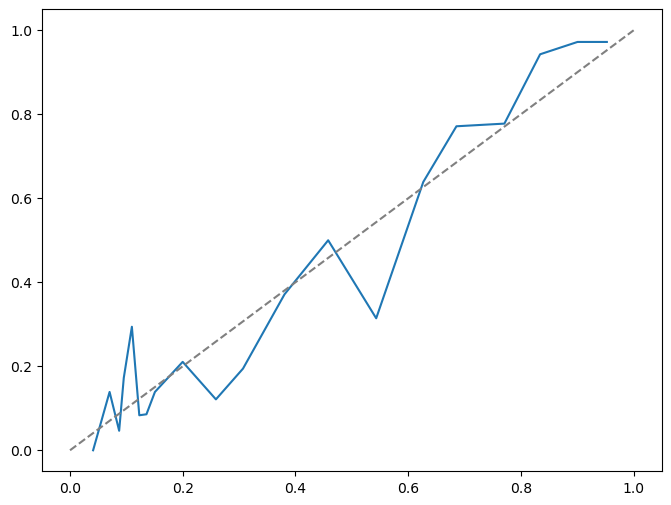

In [ ]:

y_prob = pipe_lr.predict_proba(X_train)[:,1]

prob_true, prob_pred = calibration_curve(y_train,y_prob,n_bins=10,strategy="quantile")

fig, ax = subplots(figsize=(8,6))

ax.plot(prob_pred,prob_true,label="Logistic Regression")
ax.plot([0,1],[0,1],linestyle='--',c='gray',label="Perfect Calibration")



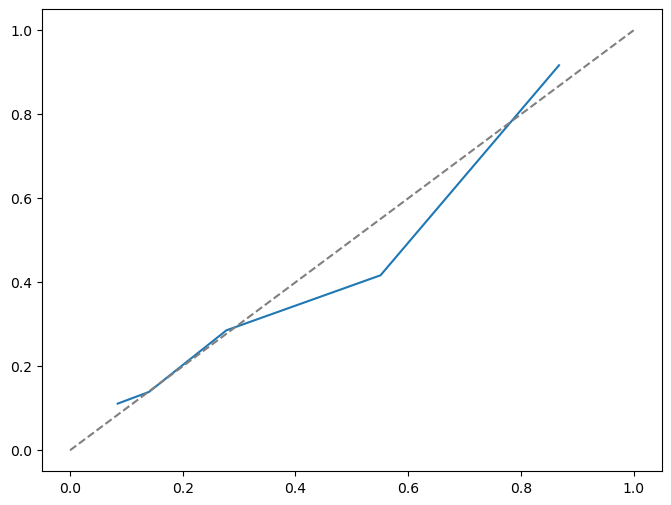

In [48]:

y_prob = pipe_lr.predict_proba(X_test)[:,1]

prob_true, prob_pred = calibration_curve(y_test,y_prob,n_bins=5,strategy="quantile")

fig, ax = subplots(figsize=(8,6))

ax.plot(prob_pred,prob_true,label="Logistic Regression")
ax.plot([0,1],[0,1],linestyle='--',c='gray',label="Perfect Calibration")


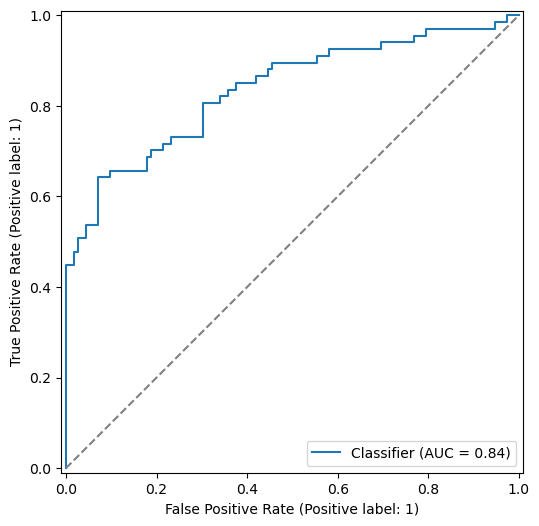

In [52]:
y_prob = pipe_lr.predict_proba(X_test)[:,1]

fig, ax = subplots(figsize=(8,6))

RocCurveDisplay.from_predictions(y_test,y_prob,ax=ax)
ax.plot([0,1],[0,1],linestyle='--',c='gray')


In [80]:
marg_df = pd.concat([X_train,y_train],axis=1).reset_index().copy()

marg_df.set_index('PassengerId')
marg_df["Sex"] = marg_df["Sex"].astype("category")
marg_df["Embarked"] = marg_df["Embarked"].astype("category")
marg_df["Pclass"] = marg_df["Pclass"].astype("category")

def selector(data):
    y = data[["Survived"]]
    X = data[["Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]]
    return y, X

model_marg = fit_sklearn(
    selector,
    data = marg_df,
    engine = pipe_lr
)

/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [83]:
print(avg_slopes(model_marg,variables=["Age","SibSp","Parch","Fare","Sex"]))

shape: (5, 3)
┌───────┬───────────────┬──────────┐
│ Term  ┆ Contrast      ┆ Estimate │
│ ---   ┆ ---           ┆ ---      │
│ str   ┆ str           ┆ str      │
╞═══════╪═══════════════╪══════════╡
│ Age   ┆ dY/dX         ┆ -0.00702 │
│ SibSp ┆ dY/dX         ┆ 0.0135   │
│ Parch ┆ dY/dX         ┆ -0.0694  │
│ Fare  ┆ dY/dX         ┆ 0.00056  │
│ Sex   ┆ male - female ┆ -0.35    │
└───────┴───────────────┴──────────┘


In [86]:
avg_comparisons(model_marg,variables = {"Age":"sd","Fare":"sd"})

term,contrast,estimate
str,str,f64
"""Age""","""(x+sd/2) - (x-sd/2)""",-0.108612
"""Fare""","""(x+sd/2) - (x-sd/2)""",0.044435


In [90]:
pipe_lr.fit(X_train,y_train)

y_prob = pipe_lr.predict_proba(X_test)[:,1]

log_loss(y_test,y_prob)


0.45751040093637685

In [94]:


preprocess_pipeline.set_output(transform="pandas")

interaction_pipe = ColumnTransformer([
    ("interact",PolynomialFeatures(degree=2,include_bias=False),
    ["num__Age","cat__Sex_male","cat__Pclass_2","cat__Pclass_3"])],
    remainder="passthrough")

pipe_int_lr = Pipeline([
    ("prep",preprocess_pipeline),
    ("interactions",interaction_pipe),
    ("model",LogisticRegression(max_iter=1000))
])

In [95]:
pipe_int_lr.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('interactions', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [96]:
y_prob = pipe_int_lr.predict_proba(X_test)[:,1]
log_loss(y_test,y_prob)

0.45164655852910923

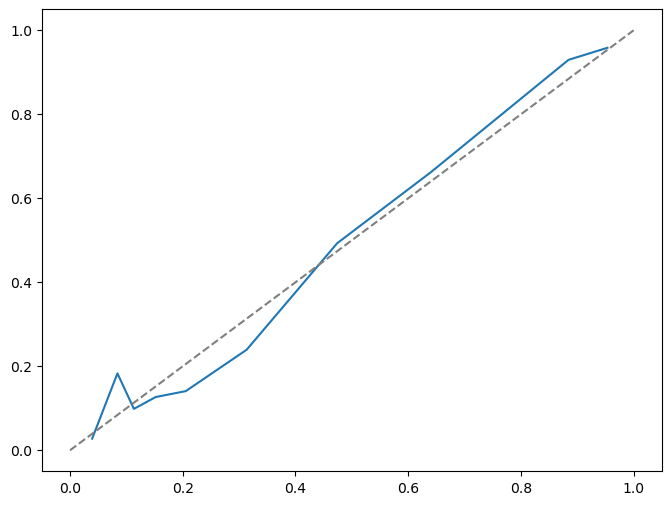

In [97]:

y_prob = pipe_int_lr.predict_proba(X_train)[:,1]

prob_true, prob_pred = calibration_curve(y_train,y_prob,n_bins=10,strategy="quantile")

fig, ax = subplots(figsize=(8,6))

ax.plot(prob_pred,prob_true,label="Interaction Logistic Regression")
ax.plot([0,1],[0,1],linestyle='--',c='gray',label="Perfect Calibration")


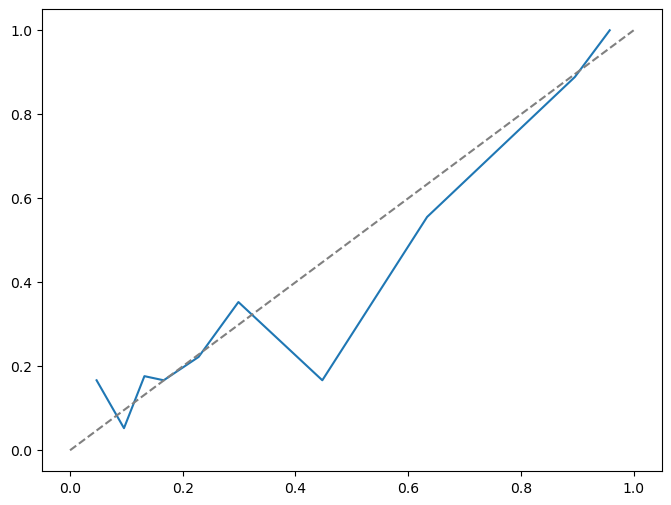

In [98]:

y_prob = pipe_int_lr.predict_proba(X_test)[:,1]

prob_true, prob_pred = calibration_curve(y_test,y_prob,n_bins=10,strategy="quantile")

fig, ax = subplots(figsize=(8,6))

ax.plot(prob_pred,prob_true,label="Interaction Logistic Regression")
ax.plot([0,1],[0,1],linestyle='--',c='gray',label="Perfect Calibration")


In [103]:
y_pred = y_prob > 0.9

print(classification_report(y_test,y_pred,target_names=["Died","Survived"]))


              precision    recall  f1-score   support

        Died       0.73      1.00      0.85       112
    Survived       1.00      0.39      0.56        67

    accuracy                           0.77       179
   macro avg       0.87      0.69      0.70       179
weighted avg       0.83      0.77      0.74       179



In [109]:
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ('prep',preprocess_pipeline),
    ("model",KNeighborsClassifier(n_neighbors=10))
])

pipe_knn.fit(X_train,y_train)
y_prob = pipe_knn.predict_proba(X_test)[:,1]

In [110]:
log_loss(y_test,y_prob)

1.4112157322648757

In [111]:
accuracy_score(y_test,pipe_knn.predict(X_test))

0.7877094972067039

In [112]:
accuracy_score(y_test,pipe_lr.predict(X_test))

/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0.7932960893854749

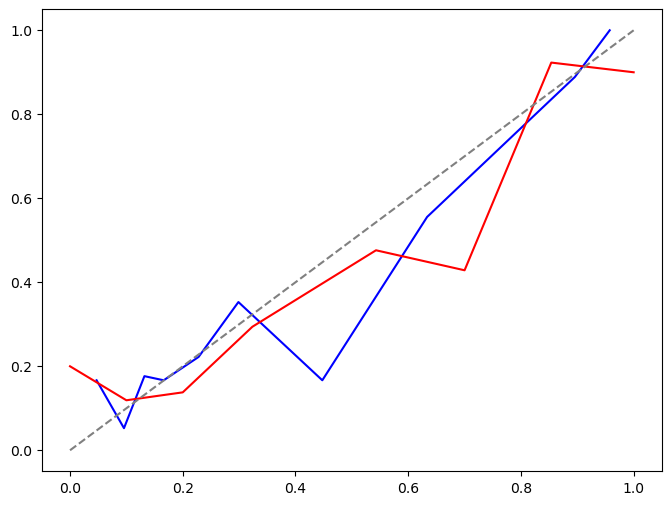

In [114]:

y_prob = pipe_knn.predict_proba(X_test)[:,1]

prob_knn_true, prob_knn_pred = calibration_curve(y_test,y_prob,n_bins=10,strategy="quantile")

fig, ax = subplots(figsize=(8,6))

ax.plot(prob_pred,prob_true,label="Interaction Logistic Regression",c='blue')
ax.plot(prob_knn_pred,prob_knn_true,label="KNN (n_neighbors=10)",c='red')

ax.plot([0,1],[0,1],linestyle='--',c='gray',label="Perfect Calibration")
